#### Notebook NetCDF to Zarr

Steps:
- download/access the data
- data conversion to Zarr
- compare data access (partial reads)
- compare two chunking strategies

In [1]:
import xarray as xr
import zarr
import matplotlib.pyplot as plt
from pathlib import Path
import cdsapi

In [2]:
# create the filestructure
datapath = Path('../data/03_era5land_netCDF')
netCDF_path = Path('../outputs/03_era5land_zarr')

datapath.mkdir(parents=True, exist_ok=True)
netCDF_path.mkdir(parents=True, exist_ok=True)

In [4]:
# the selected Era 5 data is too large to provide via github, so a downlaod is necessary from CDS -> this will take a while
# Create a CDS account and provide credentials as outlined in https://cds.climate.copernicus.eu/how-to-api

# download ERA5 data 
dataset = "reanalysis-era5-land"
request = {
    "variable": ["2m_temperature"],
    "year": "2000",
    "month": "01",
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28"
    ],
    "time": ["12:00"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

print('Downloading sample area, will take some time')
client = cdsapi.Client()
client.retrieve(dataset, request, datapath / 'data.nc')

2026-07-15 15:11:50,783 INFO Request ID is 51ed311f-b08f-4ae9-ba6e-f9f06a39405d
2026-07-15 15:11:50,856 INFO status has been updated to accepted
2026-07-15 15:12:21,888 INFO status has been updated to running
2026-07-15 15:12:36,752 INFO status has been updated to successful


PosixPath('../data/03_era5land_netCDF/data.nc')

NetCDF4 also allows chunking and is optimised for multi-dimensional data. When selecting and comparing data formats, we can also evaluate different chunking strategies: along the temporal or sptial dimension.

In [10]:
merged = xr.open_dataset(datapath / 'data.nc', engine='netcdf4', mask_and_scale=False)

# chunking strategies -> what access do we want to optimize?
# - timeseries: small local spatial lookups and across all time dimensions
# - global maps: looking at global data at a single time dimension

# time seriEs chunking
ts_data = merged.chunk({'valid_time': -1, 'latitude': 512, 'longitude': 512})
ts_data.to_zarr(netCDF_path / 'ts_data.zarr')
zarr.consolidate_metadata(netCDF_path / 'ts_data.zarr')
ts_data.to_netcdf(netCDF_path / 'ts_data.nc', format='NETCDF4', engine='netcdf4', encoding={'t2m': {"chunksizes": (merged.valid_time.shape[0], 512, 512),}})


global_data = merged.chunk({'valid_time': 1, 'latitude': 1024, 'longitude': 1024})
global_data.to_zarr(netCDF_path / 'global_data.zarr')
zarr.consolidate_metadata(netCDF_path / 'global_data.zarr')
global_data.to_netcdf(netCDF_path / 'global_data.nc', format='NETCDF4', engine='netcdf4', encoding={'t2m': {"chunksizes": (1, 1024, 1024),}})

/home/samuel/coding/cn_datacube_notebooks/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=4, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/samuel/coding/cn_datacube_notebooks/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/samuel/coding/cn_datacube_no

In [11]:
# time the access speeds
def ts_lookup(ds):
    #return ds["t2m"].sel(latitude=slice(49.2, 48.2), longitude=slice(16.4, 18.4),).mean(dim=('latitude', 'longitude')).compute()
    return ds["t2m"].sel(latitude=48.2,longitude=16.4,method="nearest",).compute()

def global_lookup(ds):
    return ds["t2m"].isel(valid_time=0).compute()

net_ts = xr.open_dataset(netCDF_path / 'ts_data.nc', engine='netcdf4', mask_and_scale=False)
net_gm = xr.open_dataset(netCDF_path / 'global_data.nc', engine='netcdf4', mask_and_scale=False)
ts = xr.open_zarr(netCDF_path / 'ts_data.zarr', mask_and_scale=False)
gm = xr.open_zarr(netCDF_path / 'global_data.zarr', mask_and_scale=False)

print('Timeseries')
%timeit ts_lookup(ts)
%timeit ts_lookup(gm)
%timeit ts_lookup(net_ts)
%timeit ts_lookup(net_gm)

print('Global')
%timeit global_lookup(ts)
%timeit global_lookup(gm)
%timeit global_lookup(net_gm)
%timeit global_lookup(net_ts)

Timeseries
23.1 ms ± 5.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
92.9 ms ± 7.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
473 μs ± 5.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
9.27 ms ± 157 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Global
134 ms ± 8.02 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
25.6 ms ± 485 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.41 ms ± 73.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
75.3 ms ± 6.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Here we can see, that on a small file in a local filesystem netCDF is faster than Zarr, as zarr has to construct dask arrays in the background, whereas netCDF directly reads the chunk however, zarr is optimised for non-local cloud storage and allows the better parallelisation.

The different chunking strategies show, that selecting the appropiate method (timeseries or large-spatial-areas) impacts the performance dramatically (irregardless of the file format!)

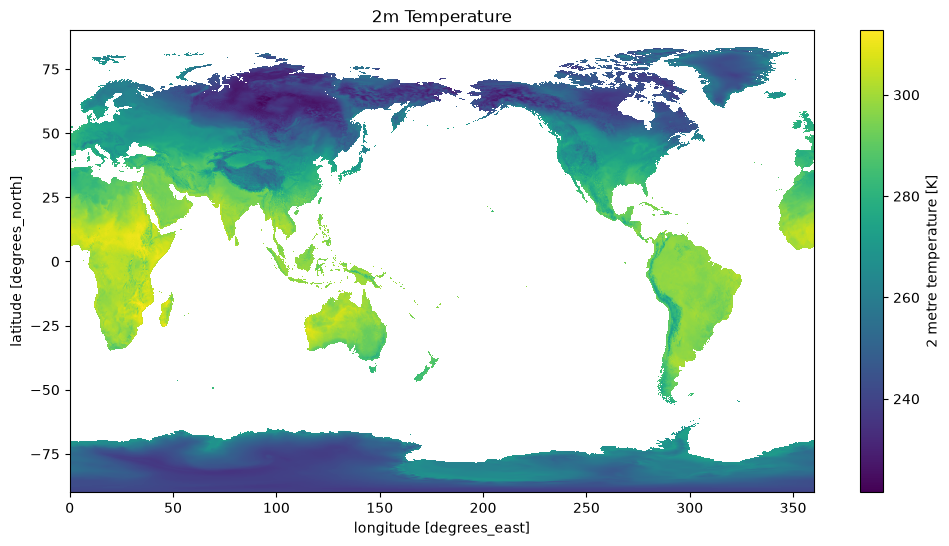

In [ ]:
# plot a global dataset for the first timestamp
merged["t2m"].isel(valid_time=0).plot(figsize=(12, 6)) # type: ignore

plt.title("2m Temperature")
plt.show()

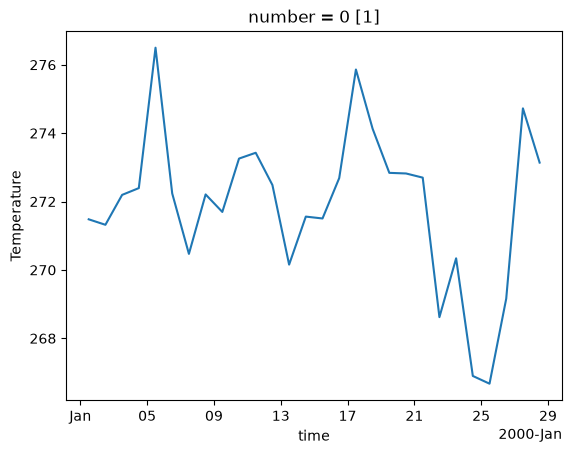

In [ ]:
# plot the data for a single spatial window across the whole month and build the mean over it
window = merged["t2m"].sel(
    latitude=slice(49.2, 48.2),
    longitude=slice(16.4, 18.4),
).mean(dim=('latitude', 'longitude'))

window.plot() # type: ignore
plt.ylabel("Temperature")
plt.show()